In this example, we show how to compute $e_{\text{gw}}$
 from an eccentric waveform generated using the `ESIGMAHM` waveform model.
We will use the python package `esigmapy` from [here](https://github.com/gwnrtools/esigmapy).
The waveform loading function used in this notebook is based on the python example provided in the documentation [here](https://github.com/gwnrtools/esigmapy/blob/master/notebooks/ESIGMA_tutorial.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from gw_eccentricity import measure_eccentricity
from gw_eccentricity.plot_settings import use_fancy_plotsettings, labelsDict

import esigmapy

/home/akash-x16/miniconda3/envs/esigma-igwn39/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


No version information file '.version' found


In [2]:
m1 = 5.0  # masses (in solar masses)
m2 = 20.0
spin1z = 0.7  # dimensionless spins
spin2z = 0.6
eccentricity = 0.3  # starting eccentricity
mean_anomaly = 60 * np.pi / 180.0  # starting mean anomaly

f_low = 20.0  # starting frequency (in Hz)
delta_t = 1 / 2**12  # time grid-spacing (in s)

modes_to_use = [(2, 2), (2, 1), (3, 3), (3, 2), (4, 4), (4, 3)] # GW modes to use

modes = esigmapy.get_imr_esigma_modes(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    include_conjugate_modes=False,
)

In [3]:
# the mode keys are already in the gw_eccentricity format
modes.keys()

dict_keys([(2, 2), (2, 1), (3, 3), (3, 2), (4, 4), (4, 3)])

## Get data dict in gw_eccentricity input format

In [4]:
def get_data_dict(modes):
    modes_dict = {}
    for k in modes.keys():
        # Extracting modes as NummPy arrays from the 
        # native modes, which are PyCBC TimeSeries objects 
        modes_dict.update({k: modes[k].data})
    t = modes[k].sample_times.data # Extracting time grid
    return {"t": t, "hlm": modes_dict}

In [5]:
data_dict = get_data_dict(modes)

## Compute $e_{\text{gw}}$

In [6]:
gwecc_dict = measure_eccentricity(
    dataDict=data_dict,
    tref_in=data_dict["t"])

In [7]:
gwecc_obj = gwecc_dict["gwecc_object"]

Text(0.5, 0, '$t$ [s] ')

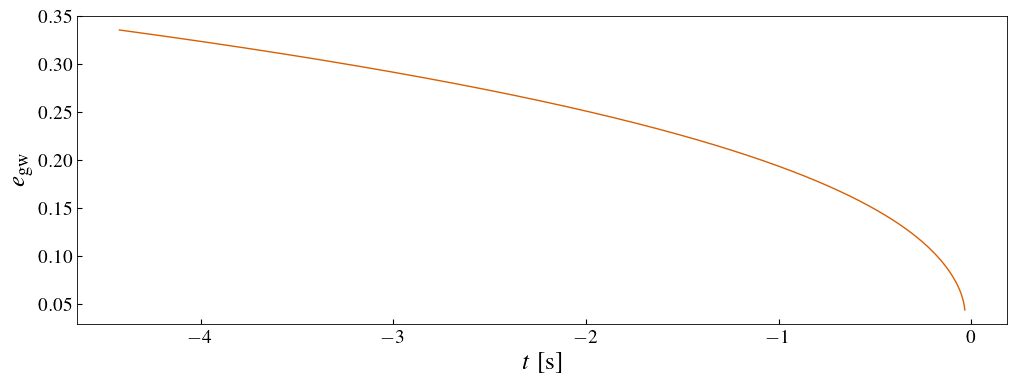

In [8]:
use_fancy_plotsettings()
fig, ax = gwecc_obj.plot_eccentricity()
ax.set_xlabel(labelsDict["t"] + " [s] ")